# **Malaria Detection**

In [2]:
# All the necessary imports for the project. Therefore, no need to import any additional libraries in the subsequent cells.
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import backend, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, SeparableConv2D, MaxPooling2D,
                                     AveragePooling2D, GlobalAveragePooling2D,
                                     Dense, Flatten, Dropout,
                                     BatchNormalization, LeakyReLU)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16

warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

# Fix seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
data_path = './cell_images'

In [4]:
train_dir = os.path.join(data_path, 'train')
test_dir  = os.path.join(data_path, 'test')

In [5]:
SIZE = 64

def load_split(split_dir, size=64):
    images, labels = [], []
    for folder_name in ['/parasitized/', '/uninfected/']:
        folder_path = split_dir + folder_name
        if not os.path.isdir(folder_path):
            continue
        for image_name in os.listdir(folder_path):
            if image_name.startswith('.'):   # skip .DS_Store etc.
                continue
            try:
                image = Image.open(folder_path + image_name).convert('RGB')
                image = image.resize((size, size))
                images.append(np.array(image))
                labels.append(1 if folder_name == '/parasitized/' else 0)
            except Exception:
                pass
    return np.array(images), np.array(labels)

print("Loading train images...")
train_images, train_labels = load_split(train_dir, SIZE)

print("Loading test images...")
test_images, test_labels = load_split(test_dir, SIZE)

print("Done.")


Loading train images...
Loading test images...
Done.


In [6]:
print(f'Train images shape : {train_images.shape}')
print(f'Test  images shape : {test_images.shape}')

Train images shape : (24958, 64, 64, 3)
Test  images shape : (2600, 64, 64, 3)


In [7]:
print(f'Train labels shape : {train_labels.shape}')
print(f'Test  labels shape : {test_labels.shape}')

Train labels shape : (24958,)
Test  labels shape : (2600,)


In [8]:
print(f'Train — Min: {np.min(train_images)}, Max: {np.max(train_images)}')
print(f'Test  — Min: {np.min(test_images)},  Max: {np.max(test_images)}')

Train — Min: 0, Max: 255
Test  — Min: 0,  Max: 255


In [9]:
unique_train, counts_train = np.unique(train_labels, return_counts=True)
unique_test,  counts_test  = np.unique(test_labels,  return_counts=True)

print("Train — Uninfected:", counts_train[0], "| Parasitized:", counts_train[1])
print("Test  — Uninfected:", counts_test[0],  "| Parasitized:", counts_test[1])

Train — Uninfected: 12376 | Parasitized: 12582
Test  — Uninfected: 1300 | Parasitized: 1300


In [10]:
train_images = (train_images / 255.0).astype('float32')
test_images  = (test_images  / 255.0).astype('float32')

print(f'After norm — Train range: [{train_images.min():.2f}, {train_images.max():.2f}]')
print(f'After norm — Test  range: [{test_images.min():.2f}, {test_images.max():.2f}]')

After norm — Train range: [0.00, 1.00]
After norm — Test  range: [0.00, 1.00]


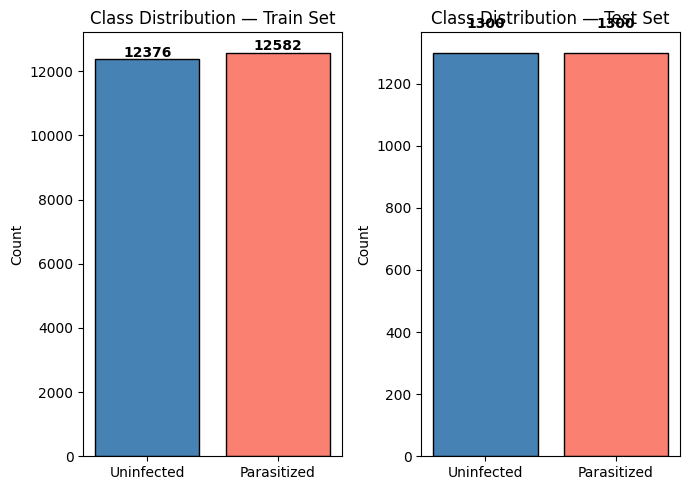

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(7, 5))
for ax, counts, title in zip(axes,
                              [counts_train, counts_test],
                              ['Train Set', 'Test Set']):
    ax.bar(['Uninfected', 'Parasitized'], counts,
           color=['steelblue', 'salmon'], edgecolor='black')
    ax.set_title(f'Class Distribution — {title}')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts):
        ax.text(i, v + 80, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150)
plt.show()


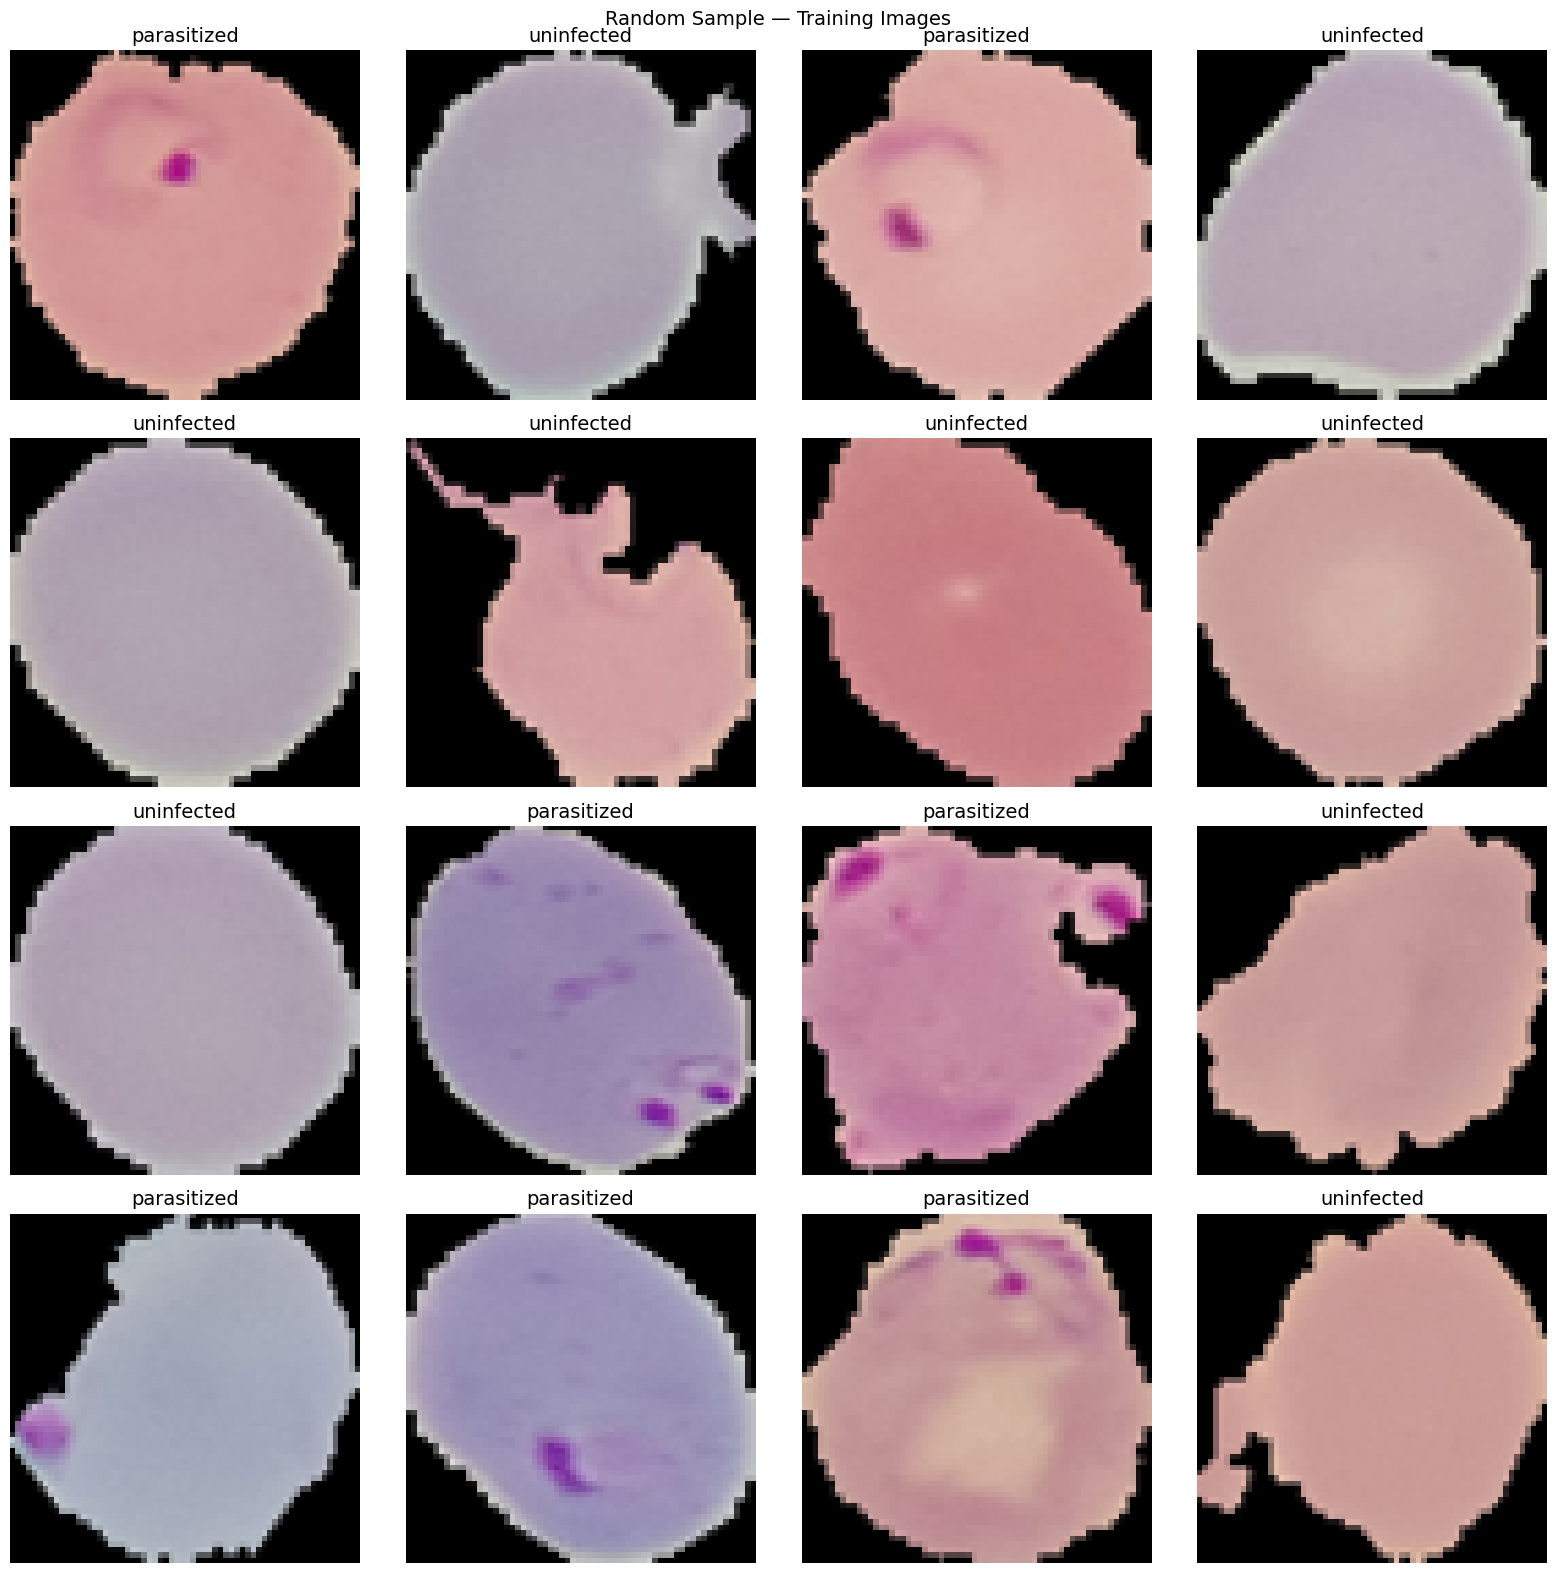

In [14]:
plt.figure(1, figsize=(16, 16))
for n in range(1, 17):
    plt.subplot(4, 4, n)
    index = int(np.random.randint(0, train_images.shape[0], 1))
    plt.title('parasitized' if train_labels[index] == 1 else 'uninfected', fontsize=14)
    plt.imshow(train_images[index])
    plt.axis('off')
plt.suptitle('Random Sample — Training Images', fontsize=14)
plt.tight_layout()
plt.savefig('sample_4x4.png', dpi=150)
plt.show()

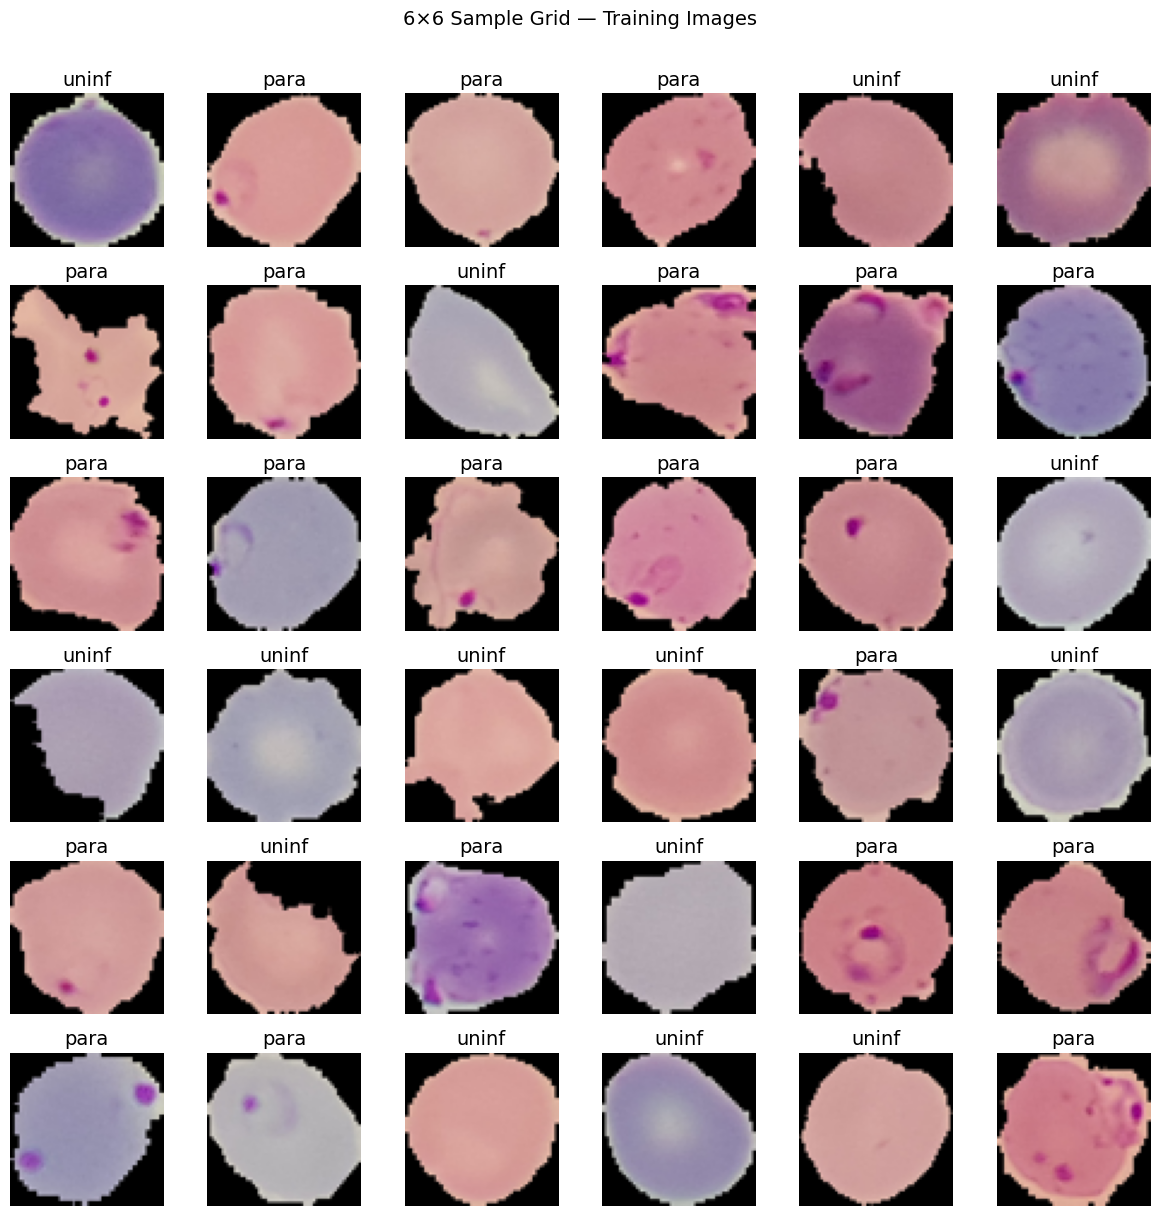

In [15]:
plt.figure(figsize=(12, 12))
for n in range(1, 37):          # 6×6 = 36 images
    plt.subplot(6, 6, n)
    index = int(np.random.randint(0, train_images.shape[0], 1))
    plt.title('para' if train_labels[index] == 1 else 'uninf', fontsize=14)
    plt.imshow(train_images[index])
    plt.axis('off')
plt.suptitle('6×6 Sample Grid — Training Images', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('sample_6x6.png', dpi=150)
plt.show()

####<b>Observations and insights:
- Across 36 images the parasitized cells still show red/purple spotting, while the uninfected appear clear and uniform consistently.
- Images vary in brightness and stain intensity, highlighting the value of normalisation and augmentation.

###<b> Plotting the mean images for parasitized and uninfected

In [16]:
def find_mean_img(full_mat, title):
    mean_img = np.mean(full_mat, axis=0)[0]
    plt.imshow(mean_img)
    plt.title(f'Average {title}')
    plt.axis('off')
    plt.show()
    return mean_img

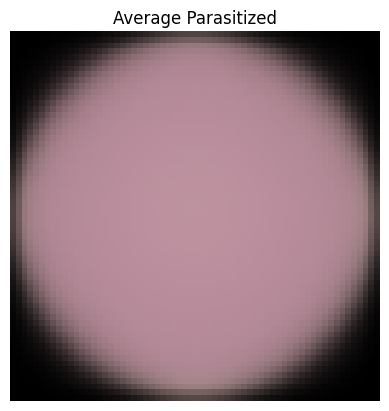

In [17]:
parasitized_data = [[img] for img, lbl in zip(train_images, train_labels) if lbl == 1]
parasitized_mean = find_mean_img(np.array(parasitized_data), 'Parasitized')

<b> Mean image for uninfected

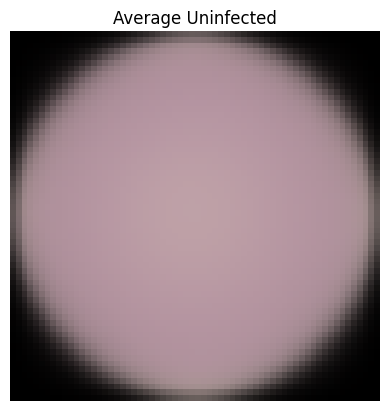

In [18]:
uninfected_data  = [[img] for img, lbl in zip(train_images, train_labels) if lbl == 0]
uninfected_mean  = find_mean_img(np.array(uninfected_data),  'Uninfected')

Converting train images to HSV...
Converting test images to HSV...


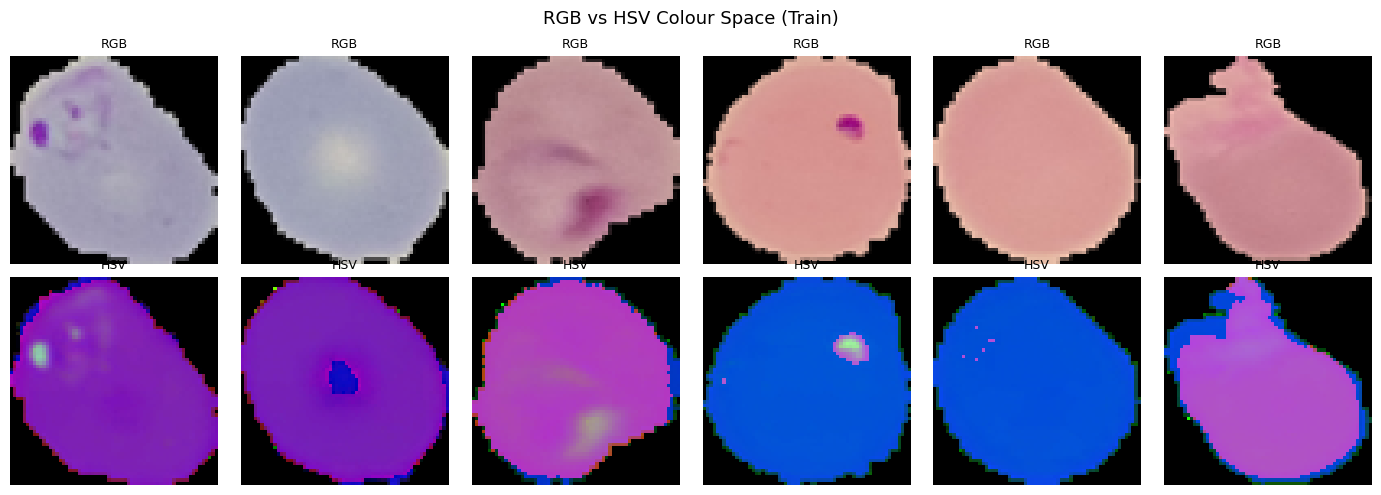

In [19]:
def convert_to_hsv(images):
    """Convert a batch of RGB images (uint8 or float) to HSV."""
    hsv_images = []
    for img in images:
        if img.max() <= 1.0:
            img_uint8 = (img * 255).astype(np.uint8)
        else:
            img_uint8 = img.astype(np.uint8)
        hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
        hsv_images.append(hsv)
    return np.array(hsv_images)

print("Converting train images to HSV...")
train_hsv = convert_to_hsv(train_images)

print("Converting test images to HSV...")
test_hsv  = convert_to_hsv(test_images)

# Visualise a few HSV samples side-by-side with their RGB counterparts (Train)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    idx = np.random.randint(0, len(train_images))
    axes[0, i].imshow(train_images[idx])
    axes[0, i].set_title('RGB', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(train_hsv[idx])
    axes[1, i].set_title('HSV', fontsize=9)
    axes[1, i].axis('off')
plt.suptitle('RGB vs HSV Colour Space (Train)', fontsize=13)
plt.tight_layout()
plt.savefig('rgb_vs_hsv.png', dpi=150)
plt.show()

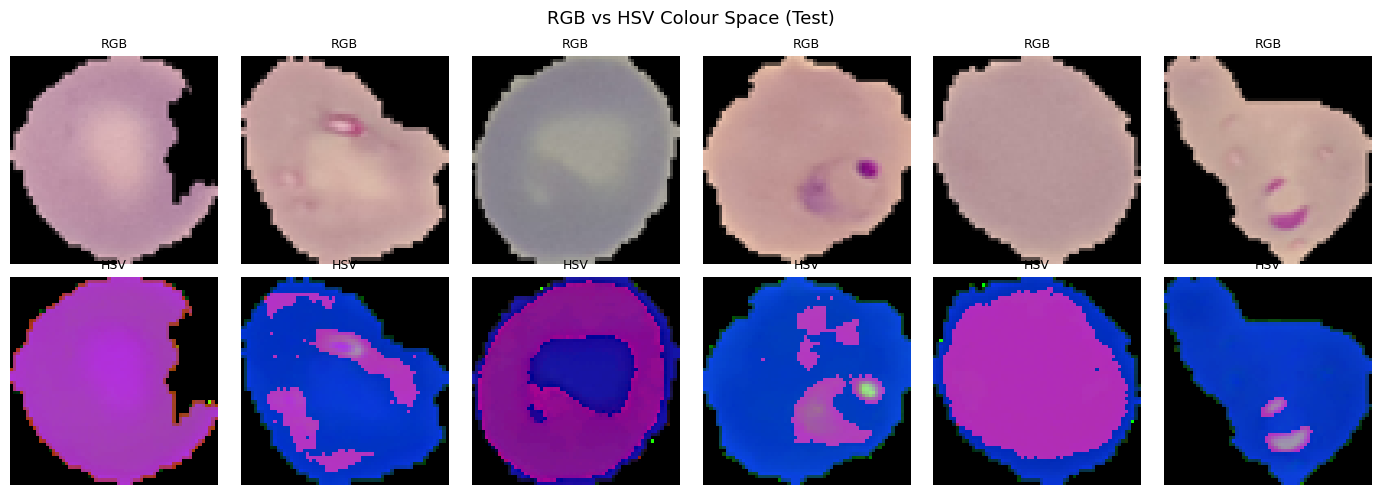

In [20]:
# Visualise a few HSV samples side-by-side with their RGB counterparts (Test)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    idx = np.random.randint(0, len(test_images))
    axes[0, i].imshow(test_images[idx])
    axes[0, i].set_title('RGB', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(test_hsv[idx])
    axes[1, i].set_title('HSV', fontsize=9)
    axes[1, i].axis('off')
plt.suptitle('RGB vs HSV Colour Space (Test)', fontsize=13)
plt.tight_layout()
plt.savefig('rgb_vs_hsv.png', dpi=150)
plt.show()

Applying Gaussian blur to train images...
Applying Gaussian blur to test images...


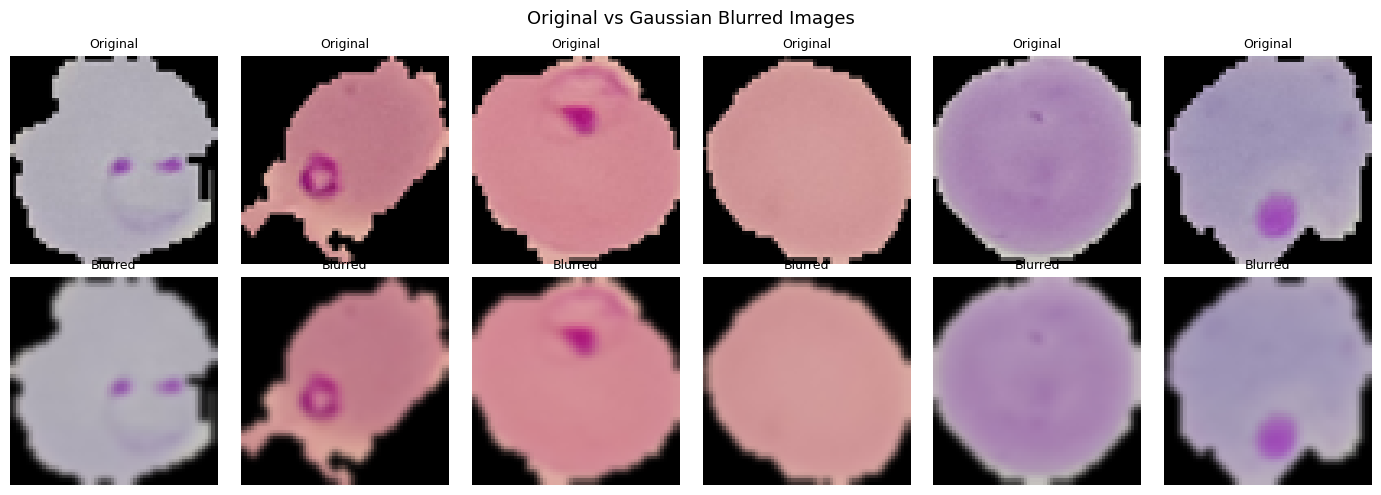

In [21]:
def apply_gaussian_blur(images, kernel_size=(5, 5)):
    blurred = []
    for img in images:
        if img.max() <= 1.0:
            img_uint8 = (img * 255).astype(np.uint8)
        else:
            img_uint8 = img.astype(np.uint8)
        blurred.append(cv2.GaussianBlur(img_uint8, kernel_size, 0))
    return np.array(blurred)

print("Applying Gaussian blur to train images...")
train_blurred = apply_gaussian_blur(train_images)

print("Applying Gaussian blur to test images...")
test_blurred  = apply_gaussian_blur(test_images)

# Visualise blur effect (Train)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    idx = np.random.randint(0, len(train_images))
    axes[0, i].imshow(train_images[idx])
    axes[0, i].set_title('Original', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(train_blurred[idx])
    axes[1, i].set_title('Blurred', fontsize=9)
    axes[1, i].axis('off')
plt.suptitle('Original vs Gaussian Blurred Images', fontsize=13)
plt.tight_layout()
plt.savefig('gaussian_blur_train.png', dpi=150)
plt.show()

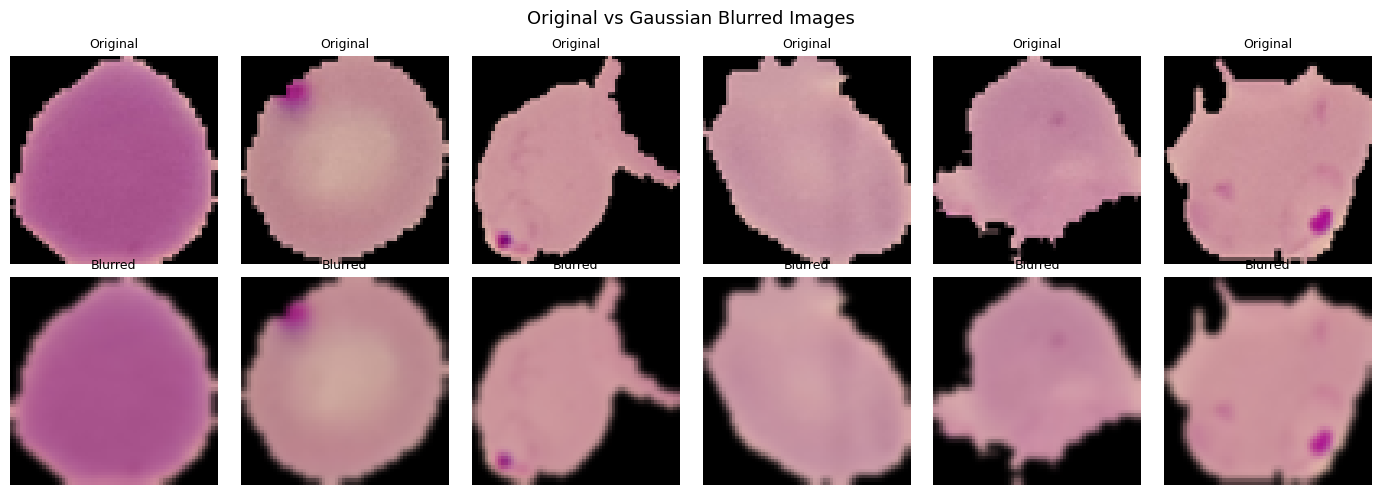

In [22]:
# Visualise blur effect (Test)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i in range(6):
    idx = np.random.randint(0, len(test_images))
    axes[0, i].imshow(test_images[idx])
    axes[0, i].set_title('Original', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(test_blurred[idx])
    axes[1, i].set_title('Blurred', fontsize=9)
    axes[1, i].axis('off')
plt.suptitle('Original vs Gaussian Blurred Images', fontsize=13)
plt.tight_layout()
plt.savefig('gaussian_blur_test.png', dpi=150)
plt.show()

In [25]:
train_labels_ohe = to_categorical(train_labels, 2)
test_labels_ohe  = to_categorical(test_labels,  2)

X_train, X_val, y_train, y_val = train_test_split(
    train_images, train_labels_ohe,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

val_classes = np.argmax(y_val, axis=1)
unique, counts = np.unique(val_classes, return_counts=True)
print(f"Val split → Uninfected: {counts[0]} | Parasitized: {counts[1]}")
print("Balanced split ready : use X_train/X_val/y_train/y_val in all models")

print(f'Train OHE shape: {train_labels_ohe.shape}')
print(f'Test  OHE shape: {test_labels_ohe.shape}')

Val split → Uninfected: 2475 | Parasitized: 2517
Balanced split ready : use X_train/X_val/y_train/y_val in all models
Train OHE shape: (24958, 2)
Test  OHE shape: (2600, 2)


In [41]:
# Helper functions for plotting accuracy/loss curves and confusion matrix/classification report.
def plot_accuracy(history, title='Model'):
    N = len(history.history['accuracy'])
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(np.arange(0, N), history.history['accuracy'],     label='train_accuracy', ls='--')
    plt.plot(np.arange(0, N), history.history['val_accuracy'], label='val_accuracy',   ls='--')
    plt.title(f'{title} — Accuracy vs Epoch')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.legend(loc='upper left')

    plt.subplot(1, 2, 2)
    plt.plot(np.arange(0, N), history.history['loss'],     label='train_loss', ls='--')
    plt.plot(np.arange(0, N), history.history['val_loss'], label='val_loss',   ls='--')
    plt.title(f'{title} — Loss vs Epoch')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=150)
    plt.show()

def plot_cm_report(model, X_test, y_test_ohe, y_test, title):
    loss, acc = model.evaluate(X_test, y_test_ohe, verbose=0)
    print(f'\n{title} — Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test_ohe, axis=1)
    print('\nClassification Report:')
    print(classification_report(y_true, pred, target_names=['Uninfected', 'Parasitized']))
    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='.0f',
                xticklabels=['Uninfected', 'Parasitized'],
                yticklabels=['Uninfected', 'Parasitized'])
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix — {title}')
    plt.tight_layout()
    plt.savefig(f'cm_{title.replace(" ", "_")}.png', dpi=150)
    plt.show()
    return acc

In [35]:
backend.clear_session()

model = Sequential()

model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu',
                 input_shape=(64, 64, 3)))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(2, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,466 (16.08 MB)

 Trainable params: 4,214,466 (16.08 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.Adam(learning_rate=0.001),
              metrics=['accuracy'])

In [37]:
callbacks = [EarlyStopping(monitor='val_loss', patience=3),
             ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)]


In [38]:
history = model.fit(X_train, y_train,
                    batch_size=64, callbacks=callbacks,
                    validation_data=(X_val, y_val),
                    epochs=20, verbose=1)

Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 55s 173ms/step - accuracy: 0.6490 - loss: 0.6526 - val_accuracy: 0.9245 - val_loss: 0.2107
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 51s 165ms/step - accuracy: 0.9213 - loss: 0.2158 - val_accuracy: 0.9447 - val_loss: 0.1569
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 56s 179ms/step - accuracy: 0.9420 - loss: 0.1625 - val_accuracy: 0.9483 - val_loss: 0.1631
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step - accuracy: 0.9504 - loss: 0.1435 - val_accuracy: 0.9613 - val_loss: 0.1296
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 47s 151ms/step - accuracy: 0.9583 - loss: 0.1178 - val_accuracy: 0.9635 - val_loss: 0.1129
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 51s 163ms/step - accuracy: 0.9629 - loss: 0.1116 - val_accuracy: 0.9677 - val_loss: 0.1093
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 50s 161ms/step - accuracy: 0.9686 - loss: 0.0951 - val_accuracy: 0.9663 - val_loss: 0.1012
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 53s 169ms/step - accuracy: 0.9726 - loss: 0

In [39]:
accuracy = model.evaluate(test_images, test_labels_ohe, verbose=1)
print('\nTest_Accuracy (Base):', accuracy[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9651 - loss: 0.1206

Test_Accuracy (Base): 0.9742307662963867



Base Model — Test Loss: 0.0937 | Test Accuracy: 0.9742 (97.42%)
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.96      0.99      0.97      1300
 Parasitized       0.99      0.96      0.97      1300

    accuracy                           0.97      2600
   macro avg       0.97      0.97      0.97      2600
weighted avg       0.97      0.97      0.97      2600



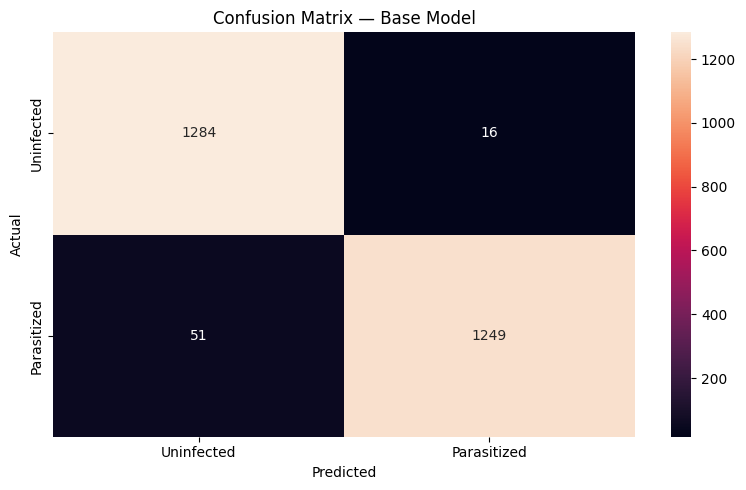

0.9742307662963867

In [42]:
plot_cm_report(model, test_images, test_labels_ohe, test_labels, 'Base Model')

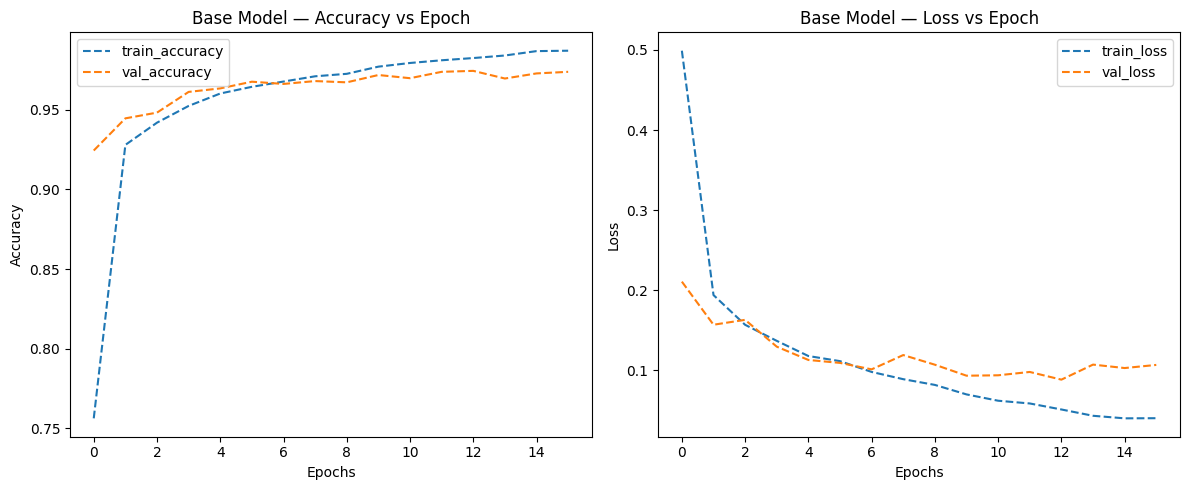

In [43]:
plot_accuracy(history, 'Base Model')

In [44]:
backend.clear_session()
from tensorflow.keras.regularizers import l2

In [45]:
model1 = Sequential()

model1.add(Conv2D(filters=32, kernel_size=3, padding='same',
                  activation='relu', kernel_regularizer=l2(1e-4),
                  input_shape=(64, 64, 3)))
model1.add(MaxPooling2D(pool_size=2))
model1.add(Dropout(0.3))

model1.add(Conv2D(filters=64, kernel_size=3, padding='same',
                  activation='relu', kernel_regularizer=l2(1e-4)))
model1.add(MaxPooling2D(pool_size=2))
model1.add(Dropout(0.3))

model1.add(Conv2D(filters=128, kernel_size=3, padding='same',
                  activation='relu', kernel_regularizer=l2(1e-4)))
model1.add(MaxPooling2D(pool_size=2))
model1.add(Dropout(0.3))

# GlobalAveragePooling collapses each feature map to one value —
# far fewer parameters than Flatten, strong built-in regularisation
model1.add(GlobalAveragePooling2D())

model1.add(Dense(128, activation='relu', kernel_regularizer=l2(1e-4)))
model1.add(Dropout(0.4))
model1.add(Dense(2, activation='softmax'))

model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,018 (429.76 KB)

 Trainable params: 110,018 (429.76 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model1.compile(loss='categorical_crossentropy',
               optimizer=optimizers.Adam(learning_rate=0.0005),  # halved from 0.001
               metrics=['accuracy'])

In [47]:
callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
             ModelCheckpoint('best_model2.keras', monitor='val_loss', save_best_only=True)]

In [48]:
history1 = model1.fit(X_train, y_train,
                       batch_size=64, callbacks=callbacks,
                       validation_data=(X_val, y_val),
                       epochs=30, verbose=1)


Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 57s 178ms/step - accuracy: 0.5683 - loss: 0.6980 - val_accuracy: 0.7081 - val_loss: 0.6201
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 65s 210ms/step - accuracy: 0.7288 - loss: 0.5751 - val_accuracy: 0.9291 - val_loss: 0.2172
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 72s 178ms/step - accuracy: 0.9259 - loss: 0.2335 - val_accuracy: 0.9587 - val_loss: 0.1445
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 58s 184ms/step - accuracy: 0.9516 - loss: 0.1611 - val_accuracy: 0.9688 - val_loss: 0.1240
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 54s 175ms/step - accuracy: 0.9642 - loss: 0.1413 - val_accuracy: 0.9710 - val_loss: 0.1190
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 59s 189ms/step - accuracy: 0.9684 - loss: 0.1254 - val_accuracy: 0.9724 - val_loss: 0.1113
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 56s 179ms/step - accuracy: 0.9718 - loss: 0.1146 - val_accuracy: 0.9766 - val_loss: 0.0986
Epoch 8/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 55s 175ms/step - accuracy: 0.9741 - loss: 0

###<b> Evaluating the model

In [49]:
accuracy1 = model1.evaluate(test_images, test_labels_ohe, verbose=1)
print('\nTest_Accuracy (Model 1):', accuracy1[1])


82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9858 - loss: 0.0626

Test_Accuracy (Model 1): 0.9873076677322388



Model 1 — Test Loss: 0.0574 | Test Accuracy: 0.9873 (98.73%)
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.99      0.99      0.99      1300
 Parasitized       0.99      0.99      0.99      1300

    accuracy                           0.99      2600
   macro avg       0.99      0.99      0.99      2600
weighted avg       0.99      0.99      0.99      2600



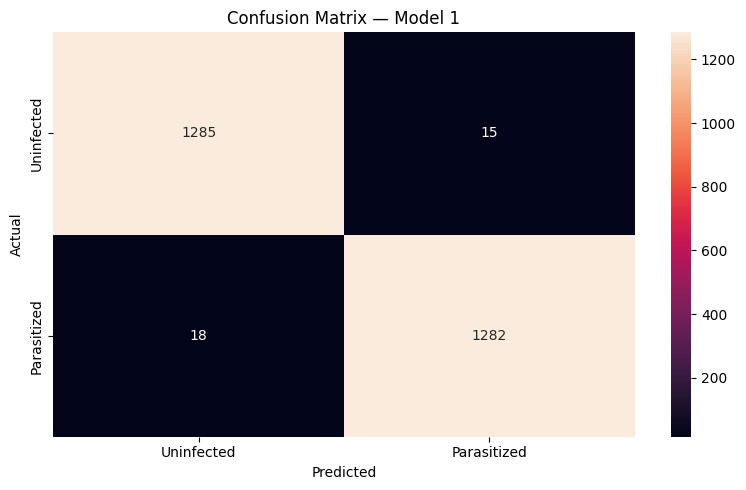

0.9873076677322388

In [50]:
plot_cm_report(model1, test_images, test_labels_ohe, test_labels, 'Model 1')

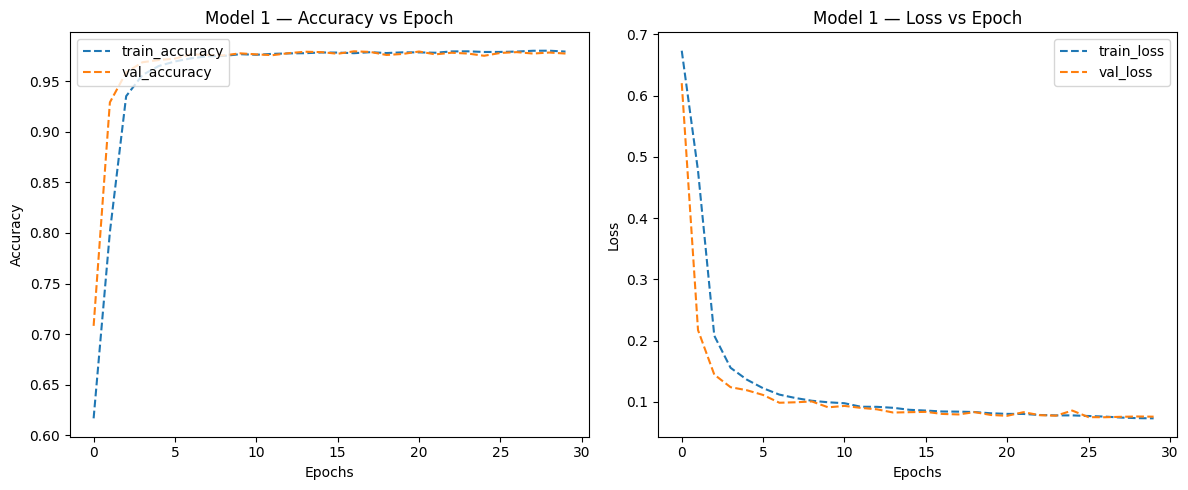

In [51]:
plot_accuracy(history1, 'Model 1')

In [108]:
backend.clear_session()

In [109]:
model2 = Sequential()

model2.add(SeparableConv2D(32, (3, 3), padding='same',
                            depthwise_regularizer=l2(1e-4),
                            pointwise_regularizer=l2(1e-4),
                            input_shape=(64, 64, 3)))
model2.add(LeakyReLU(negative_slope=0.1))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=2))

# Block 2
model2.add(SeparableConv2D(64, (3, 3), padding='same',
                            depthwise_regularizer=l2(1e-4),
                            pointwise_regularizer=l2(1e-4)))
model2.add(LeakyReLU(negative_slope=0.1))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=2))

# Block 3 — reduced to 64 filters (was 128) to limit capacity
model2.add(SeparableConv2D(64, (3, 3), padding='same',
                            depthwise_regularizer=l2(1e-4),
                            pointwise_regularizer=l2(1e-4)))
model2.add(LeakyReLU(negative_slope=0.1))
model2.add(BatchNormalization())
model2.add(MaxPooling2D(pool_size=2))

model2.add(GlobalAveragePooling2D())
model2.add(Dense(128, kernel_regularizer=l2(1e-4)))
model2.add(LeakyReLU(negative_slope=0.1))
model2.add(Dropout(0.4))
model2.add(Dense(2, activation='softmax'))

adam = optimizers.Adam(learning_rate=0.0001)

model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 64, 64, 32)     │           155 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 32, 32, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 16, 16, 64)     │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,509 (64.49 KB)

 Trainable params: 16,189 (63.24 KB)

 Non-trainable params: 320 (1.25 KB)

###<b>Compiling the model

In [111]:
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

In [112]:
callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
             ModelCheckpoint('best_model3.keras', monitor='val_loss', save_best_only=True)]

In [113]:
history2 = model2.fit(X_train, y_train,
                       batch_size=64, callbacks=callbacks,
                       validation_data=(X_val, y_val),
                       epochs=30, verbose=1)

Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 56s 175ms/step - accuracy: 0.5571 - loss: 0.7163 - val_accuracy: 0.4958 - val_loss: 0.7272
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.6682 - loss: 0.6361 - val_accuracy: 0.6070 - val_loss: 0.6565
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 54s 173ms/step - accuracy: 0.7296 - loss: 0.5761 - val_accuracy: 0.7280 - val_loss: 0.5467
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 50s 161ms/step - accuracy: 0.7896 - loss: 0.5031 - val_accuracy: 0.8079 - val_loss: 0.4298
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 50s 160ms/step - accuracy: 0.8622 - loss: 0.3887 - val_accuracy: 0.9219 - val_loss: 0.2863
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 50s 160ms/step - accuracy: 0.9132 - loss: 0.2812 - val_accuracy: 0.9451 - val_loss: 0.2054
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 49s 158ms/step - accuracy: 0.9348 - loss: 0.2127 - val_accuracy: 0.9459 - val_loss: 0.2057
Epoch 8/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 49s 157ms/step - accuracy: 0.9458 - loss: 0

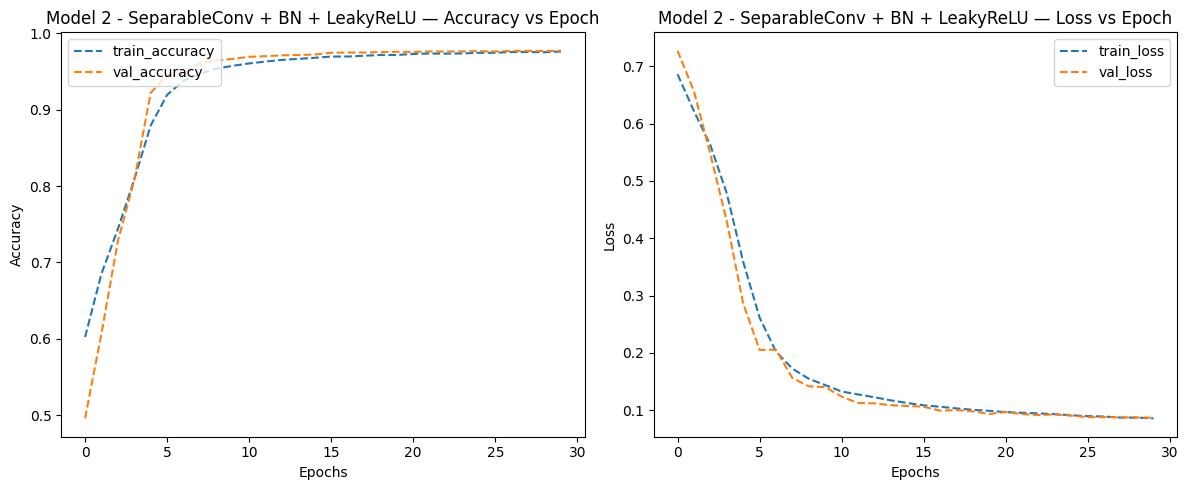

In [114]:
plot_accuracy(history2, 'Model 2 - SeparableConv + BN + LeakyReLU')

In [115]:
accuracy2 = model2.evaluate(test_images, test_labels_ohe, verbose=1)
print('\nTest_Accuracy (Model 2):', accuracy2[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9849 - loss: 0.0594

Test_Accuracy (Model 2): 0.982692301273346



Model 2 SeparableConv BN LeakyReLU — Test Loss: 0.0704 | Test Accuracy: 0.9827 (98.27%)
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.99      0.98      0.98      1300
 Parasitized       0.98      0.99      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600



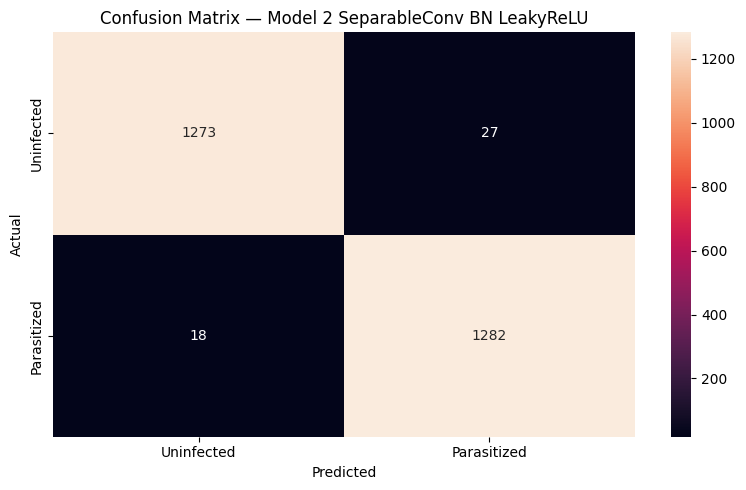

0.982692301273346

In [116]:
plot_cm_report(model2, test_images, test_labels_ohe, test_labels,
               'Model 2 SeparableConv BN LeakyReLU')

In [128]:
backend.clear_session()

In [129]:
train_datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator()

In [130]:
train_generator = train_datagen.flow(x=X_train, y=y_train,
                                     batch_size=32, seed=42, shuffle=True)
val_generator   = val_datagen.flow(x=X_val, y=y_val,
                                   batch_size=32, seed=42, shuffle=True)

###**Think About It :**<br>

*  Check if the performance of the model can be improved by changing different parameters in the ImageDataGenerator.



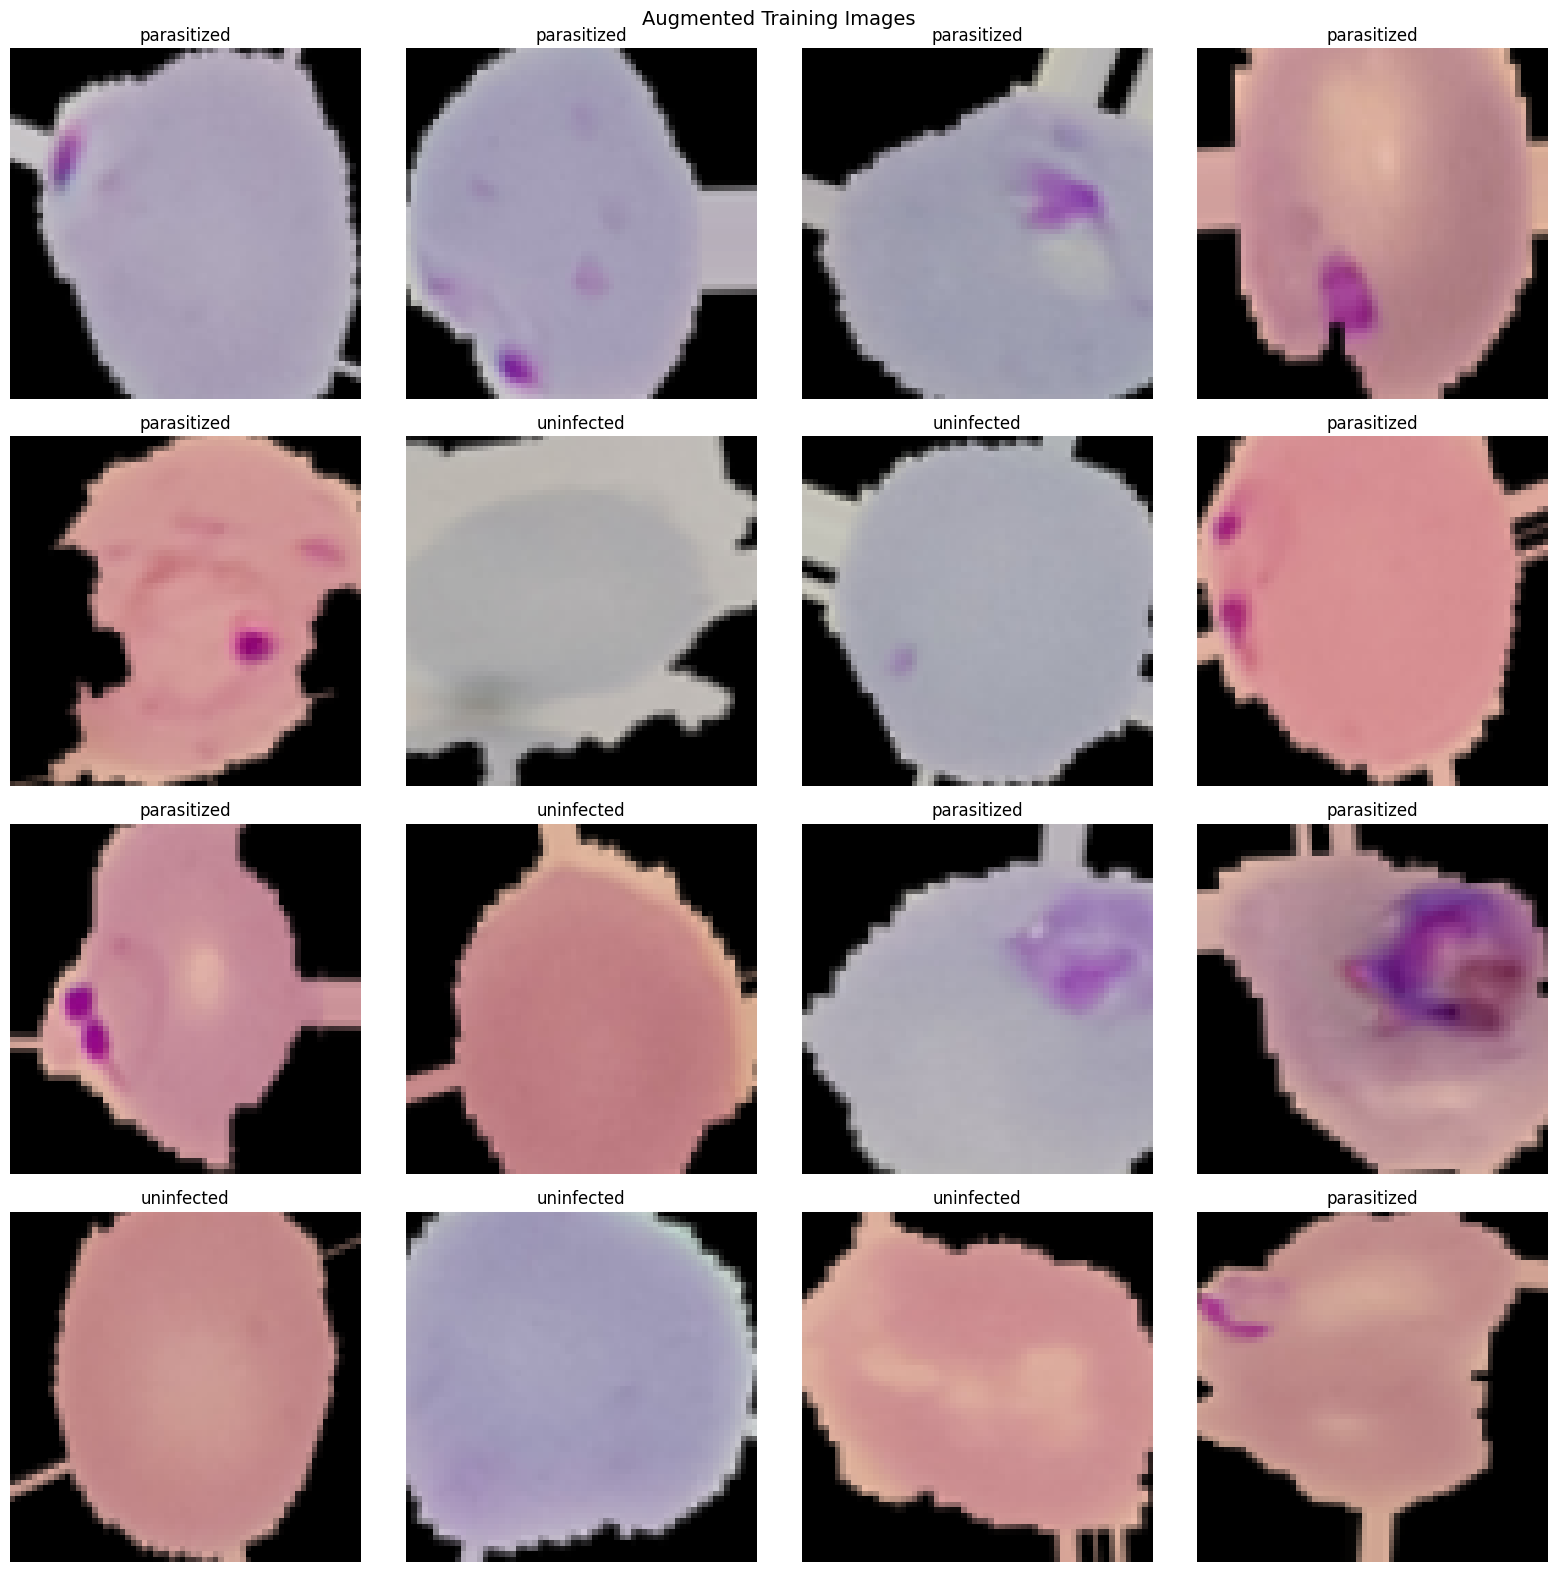

In [131]:
images_viz, labels_viz = next(train_generator)
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for (image, label, ax) in zip(images_viz, labels_viz, axes.flatten()):
    ax.imshow(np.clip(image, 0, 1))
    ax.set_title('parasitized' if label[1] == 1 else 'uninfected')
    ax.axis('off')
plt.suptitle('Augmented Training Images', fontsize=14)
plt.tight_layout()
plt.savefig('augmented_images.png', dpi=150)
plt.show()

In [134]:
train_generator = train_datagen.flow(x=X_train, y=y_train,
                                     batch_size=32, seed=42, shuffle=True)
val_generator   = val_datagen.flow(x=X_val, y=y_val,
                                   batch_size=32, seed=42, shuffle=True)


In [135]:
model3 = Sequential()

model3.add(Conv2D(32, (3, 3), padding='same', activation='relu',
                  input_shape=(64, 64, 3)))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.25))

model3.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.25))

model3.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model3.add(MaxPooling2D(pool_size=2))
model3.add(Dropout(0.25))

model3.add(GlobalAveragePooling2D())
model3.add(Dense(128, activation='relu'))
model3.add(Dropout(0.5))
model3.add(Dense(2, activation='softmax'))

adam = optimizers.Adam(learning_rate=0.001)
model3.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
model3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,018 (429.76 KB)

 Trainable params: 110,018 (429.76 KB)

 Non-trainable params: 0 (0.00 B)

In [136]:
callbacks = [EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
             ModelCheckpoint('best_model4.keras', monitor='val_loss', save_best_only=True)]

In [137]:
history3 = model3.fit(
    train_generator,
    validation_data=val_generator,
    batch_size=32,
    callbacks=callbacks,
    epochs=30, verbose=1
)

Epoch 1/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 67s 105ms/step - accuracy: 0.5599 - loss: 0.6716 - val_accuracy: 0.9231 - val_loss: 0.2379
Epoch 2/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 58s 94ms/step - accuracy: 0.9111 - loss: 0.2697 - val_accuracy: 0.9645 - val_loss: 0.1225
Epoch 3/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 58s 92ms/step - accuracy: 0.9549 - loss: 0.1554 - val_accuracy: 0.9730 - val_loss: 0.0883
Epoch 4/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.9638 - loss: 0.1174 - val_accuracy: 0.9740 - val_loss: 0.0868
Epoch 5/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9662 - loss: 0.1088 - val_accuracy: 0.9762 - val_loss: 0.0830
Epoch 6/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.9702 - loss: 0.0962 - val_accuracy: 0.9768 - val_loss: 0.0725
Epoch 7/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.9743 - loss: 0.0898 - val_accuracy: 0.9752 - val_loss: 0.0712
Epoch 8/30
624/624 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.9678 - loss: 0.1062 -

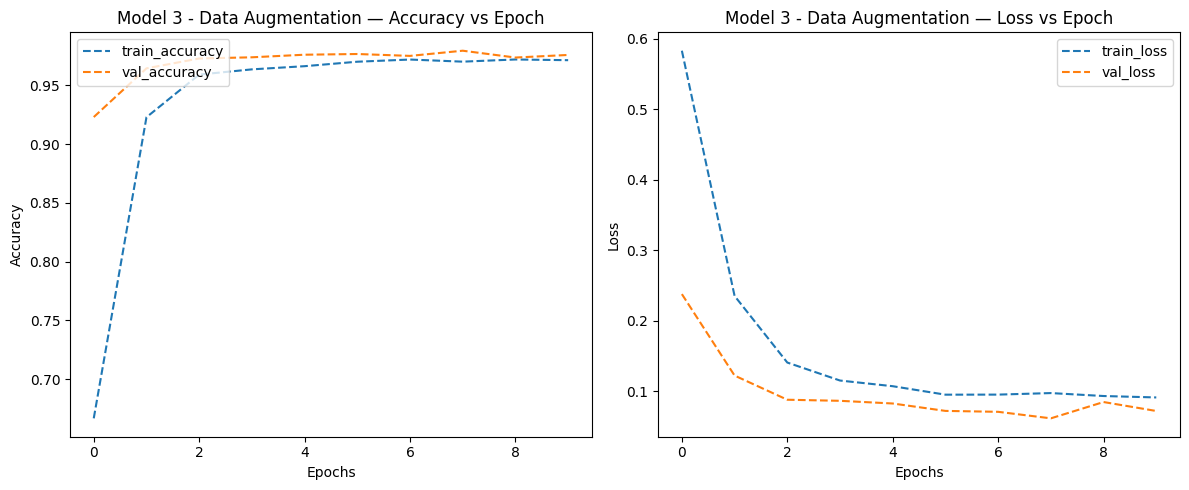

In [138]:
plot_accuracy(history3, 'Model 3 - Data Augmentation')

82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9814 - loss: 0.0463

Test_Accuracy (Model 3): 0.9819231033325195

Model 3 Data Augmentation — Test Loss: 0.0499 | Test Accuracy: 0.9819 (98.19%)
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.98      0.98      0.98      1300
 Parasitized       0.98      0.98      0.98      1300

    accuracy                           0.98      2600
   macro avg       0.98      0.98      0.98      2600
weighted avg       0.98      0.98      0.98      2600



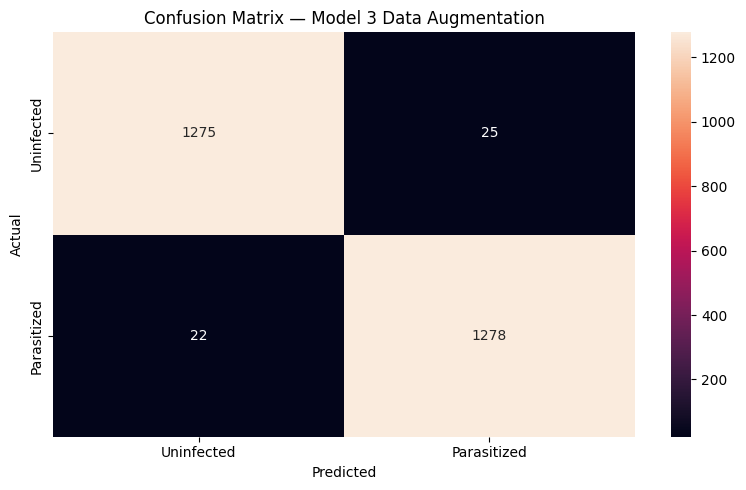

0.9819231033325195

In [139]:
accuracy3 = model3.evaluate(test_images, test_labels_ohe, verbose=1)
print('\nTest_Accuracy (Model 3):', accuracy3[1])

plot_cm_report(model3, test_images, test_labels_ohe, test_labels,
               'Model 3 Data Augmentation')

In [147]:
backend.clear_session()

vgg = VGG16(include_top=False, weights='imagenet', input_shape=(64, 64, 3))
vgg.summary()

vgg.trainable = False

transfer_layer = vgg.get_layer('block4_pool')

x = GlobalAveragePooling2D()(transfer_layer.output)   # GAP vs Flatten in provided
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
pred = Dense(2, activation='softmax')(x)

model4 = Model(vgg.input, pred)
model4.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,030,786 (30.64 MB)

 Trainable params: 395,010 (1.51 MB)

 Non-trainable params: 7,635,776 (29.13 MB)

In [148]:
model4.compile(loss='categorical_crossentropy',
               optimizer=optimizers.Adam(learning_rate=0.0001),
               metrics=['accuracy'])

In [149]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model5.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

In [150]:
history4 = model4.fit(
    X_train, y_train,
    epochs=30,
    callbacks=callbacks,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - accuracy: 0.7652 - loss: 0.5170 - val_accuracy: 0.9281 - val_loss: 0.1965 - learning_rate: 1.0000e-04
Epoch 2/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 345s 1s/step - accuracy: 0.9149 - loss: 0.2225 - val_accuracy: 0.9553 - val_loss: 0.1241 - learning_rate: 1.0000e-04
Epoch 3/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - accuracy: 0.9312 - loss: 0.1829 - val_accuracy: 0.9577 - val_loss: 0.1182 - learning_rate: 1.0000e-04
Epoch 4/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 303s 972ms/step - accuracy: 0.9423 - loss: 0.1623 - val_accuracy: 0.9611 - val_loss: 0.1113 - learning_rate: 1.0000e-04
Epoch 5/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 301s 966ms/step - accuracy: 0.9414 - loss: 0.1547 - val_accuracy: 0.9569 - val_loss: 0.1195 - learning_rate: 1.0000e-04
Epoch 6/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 301s 965ms/step - accuracy: 0.9497 - loss: 0.1446 - val_accuracy: 0.9635 - val_loss: 0.1024 - learning_rate: 1.0000e-04
Epoch 7/30
312/312 ━━━━━━━━━━━━━━━━━━━━ 306s 983m

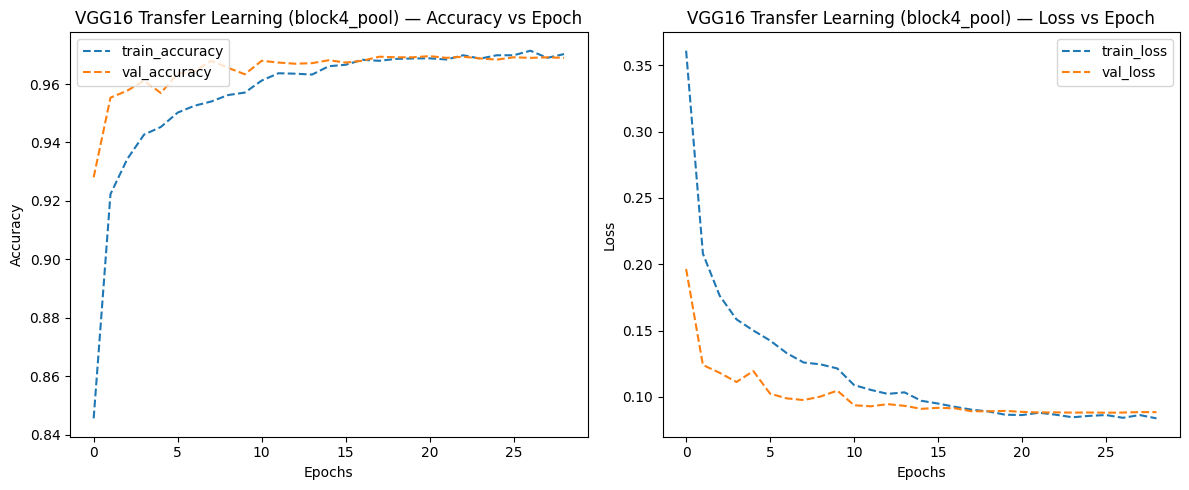

In [151]:
plot_accuracy(history4, 'VGG16 Transfer Learning (block4_pool)')

In [152]:
accuracy4 = model4.evaluate(test_images, test_labels_ohe, verbose=1)
print('\nTest_Accuracy (VGG16):', accuracy4[1])

82/82 ━━━━━━━━━━━━━━━━━━━━ 33s 392ms/step - accuracy: 0.9746 - loss: 0.0730

Test_Accuracy (VGG16): 0.9680769443511963



VGG16 Transfer Learning — Test Loss: 0.0904 | Test Accuracy: 0.9681 (96.81%)
82/82 ━━━━━━━━━━━━━━━━━━━━ 32s 395ms/step

Classification Report:
              precision    recall  f1-score   support

  Uninfected       0.98      0.96      0.97      1300
 Parasitized       0.96      0.98      0.97      1300

    accuracy                           0.97      2600
   macro avg       0.97      0.97      0.97      2600
weighted avg       0.97      0.97      0.97      2600



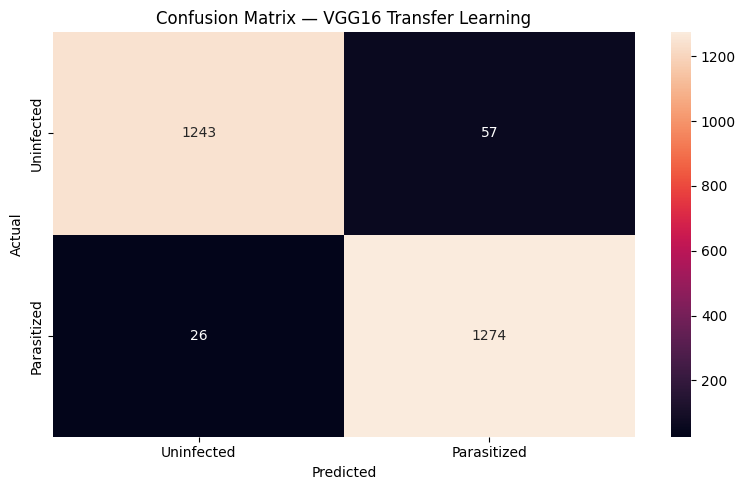

0.9680769443511963

In [153]:
plot_cm_report(model4, test_images, test_labels_ohe, test_labels,
               'VGG16 Transfer Learning')